## Excersice

1. Clusterine se define como el area del ml que permita usar algoritmos no supervisados, es decir, que no se requieren labels o semi-supervisados, los cuales requieren pocas labels para poder propagarse y etiquetar por subgrupos llamados clusters a diversas instancias de manera multidimensiona, existen muchos algoritmos como:
    - Kmeans
    - DBSCAN
    - IsolationForest
    - GMM
    - BMM
2. Las aplicaciones se basan en detección de outliers que es cuando hay un dataset con ruido y se quieren detectar cuales son aquellas instancias que se alejan de ser clasificadas en algún cluster, luego esta en si el clusterng, limpieza de datasets, incluso generación de nuevas instancias  a partir de algoritmos como GMM, dado un dataset "limpio" detectar instancias en data nueva que puedan ser ruido.

3. Sillhout method y inertia con elbow method, en sillhoutte se suele hacer un grafico de cuchillas, la idea es que el score promedio cruce la cantidad de cuchillas que son igual al numero de clusters, y que sean de una medida similar en cuanto a grosor y forma

4. la propagación es una metodología de labeling, la cual ayuda a tomar instancias importantes para cada cluster que esten incluso en los centroides y tomarlas como importantes, esto ayuda a no hacer a mano todo labeling, sino, tomar esas importantes ponerles el label y posteriormente propagar los vecinos de estas instancias importantes

5. El BIRCH es un algoritmo optimizado para datasets gigantes, para densidad DBSCAN es un agolitmo basado en densidad de puntis, y también los es GMM, el primero se basa en la construcción de un árbol de características, el segundo se basa en la densidad de puntos para formar clusters, y el tercero se basa en la suposición de que los datos se distribuyen como una mezcla de gaussianas, cada una con su propia media y covarianza.

6. Es el ciclo que se comento al inicio, es una metodología basada en que el algoritmo sugiere aquellas instancias que el usario debe de llenar para mejorar su presición. Posteriormente este conocimiento se usa para progpagar estiquetas a otras instancias, y luego se vuelve a entrenar el modelo con estas nuevas etiquetas, y se repite este proceso hasta que el modelo alcance un rendimiento satisfactorio.

7. La diferencia implica en que la primera es para encontrar esas intancias raras en un dataset y sucio, la segunda es para claificar como novedad en un datset limpio.

8. el gaussian mixture asume que los dstos son mezclas gaussianas por lo que modela y representa los datos como grupo con diversas gaussianas, puede generar nuevas instancias a partir de este aprendizaje, para detección de anomalias y novelty detection.

9. Se suele utilizar el Bayesian Mixture Model, el cual ayuda a chequear estadisticamente la importancia de los clusters, dependiendo de la cantidad que coloques, también se puede enccontrar el nmuero optimo de cluster con el BIC y el AIC, ambos son criterios de información que penalizan la complejidad del modelo, ayudando a encontrar un equilibrio entre el ajuste del modelo y su complejidad. El BIC tiende a penalizar más los modelos complejos que el AIC, por lo que a menudo se prefiere el BIC para la selección de modelos en clustering.

10. The classic Olivetti faces dataset contains 400 grayscale 64 × 64–pixel images of
faces. Each image is flattened to a 1D vector of size 4,096. Forty different people
were photographed (10 times each), and the usual task is to train a model that
can predict which person is represented in each picture. Load the dataset using
the sklearn.datasets.fetch_olivetti_faces() function, then split it into a
training set, a validation set, and a test set (note that the dataset is already scaled
between 0 and 1). Since the dataset is quite small, you will probably want to
use stratified sampling to ensure that there are the same number of images per
person in each set. Next, cluster the images using k-means, and ensure that you
have a good number of clusters (using one of the techniques discussed in this
chapter). Visualize the clusters: do you see similar faces in each cluster?

In [1]:
from sklearn.datasets import fetch_olivetti_faces

def load_olivetti_faces():
    """
    Load the Olivetti faces dataset.

    Returns:
        data (numpy.ndarray): The images of faces.
        target (numpy.ndarray): The labels corresponding to each face image.
    """
    dataset = fetch_olivetti_faces()
    data = dataset.data
    target = dataset.target
    return data, target

data, target = load_olivetti_faces()

In [2]:
# Print the shape of the data and target arrays
print("Data shape:", data.shape)
print("Target shape:", target.shape)

Data shape: (400, 4096)
Target shape: (400,)


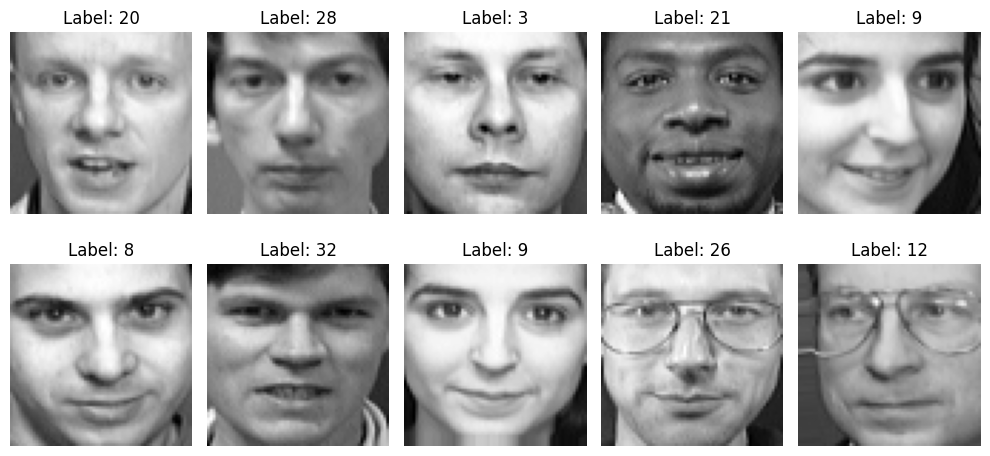

In [3]:
# Print 10 random faces 64x64 pixels
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Select 10 random indices
random_indices = np.random.choice(data.shape[0], size=10, replace=False)

# Plot the selected faces
plt.figure(figsize=(10, 5))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(data[idx].reshape(64, 64), cmap='gray')
    plt.title(f"Label: {target[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

The inidications said that we need to tratify per person, because there are 10 photos per person on the dataset so the next step is to split the dataset into training, validation, and test sets while maintaining the same number of images per person in each set. This can be done using stratified sampling.

In [4]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    data, target, test_size=0.2, random_state=42, stratify=target
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=42, stratify=y_train_val
)

# Print the shapes of the training, validation, and testing sets
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)

Training set shape: (280, 4096) (280,)
Validation set shape: (40, 4096) (40,)


Procesando k = 10 | Silhouette Score: 0.0840
Procesando k = 20 | Silhouette Score: 0.0816
Procesando k = 30 | Silhouette Score: 0.1263
Procesando k = 40 | Silhouette Score: 0.1403
Procesando k = 50 | Silhouette Score: 0.1599
Procesando k = 60 | Silhouette Score: 0.1722
Procesando k = 70 | Silhouette Score: 0.1890
Procesando k = 80 | Silhouette Score: 0.1931
Procesando k = 90 | Silhouette Score: 0.1899
Procesando k = 100 | Silhouette Score: 0.2033


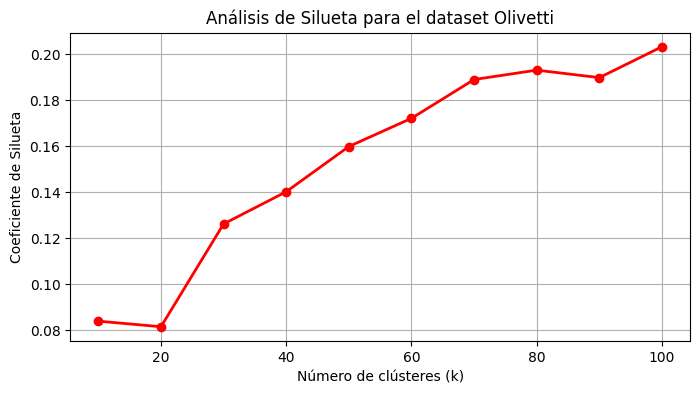

In [5]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Probar diferentes valores de k (de 10 en 10 para cuidar tu memoria RAM)
k_range = range(10, 110, 10)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train)
    
    # Calculamos el score usando las características y las etiquetas predichas
    score = silhouette_score(X_train, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"Procesando k = {k} | Silhouette Score: {score:.4f}")

# Graficar el resultado
plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, "ro-", linewidth=2)
plt.xlabel("Número de clústeres (k)")
plt.ylabel("Coeficiente de Silueta")
plt.title("Análisis de Silueta para el dataset Olivetti")
plt.grid(True)
plt.show()

c:\Users\sergi\.venvs\ml-cuda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


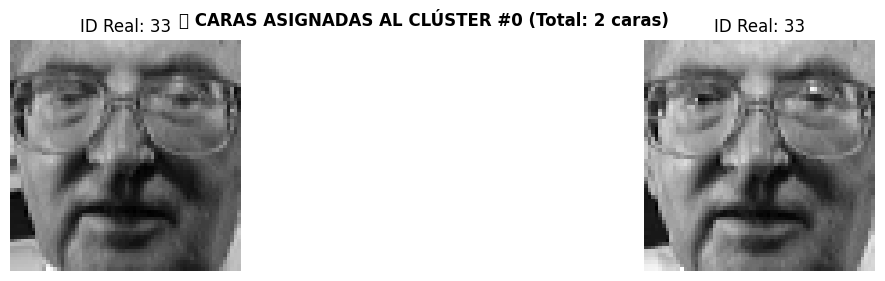

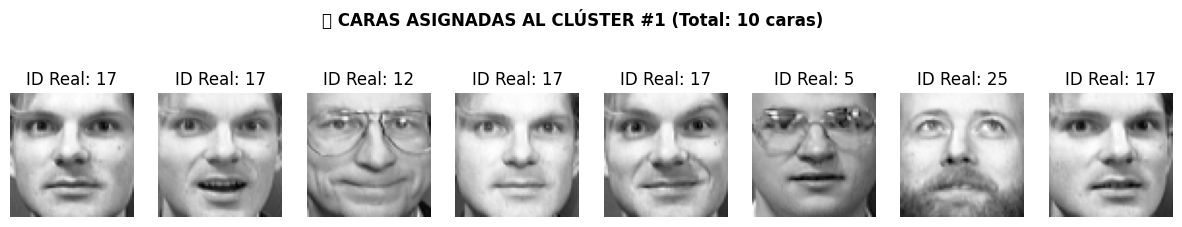

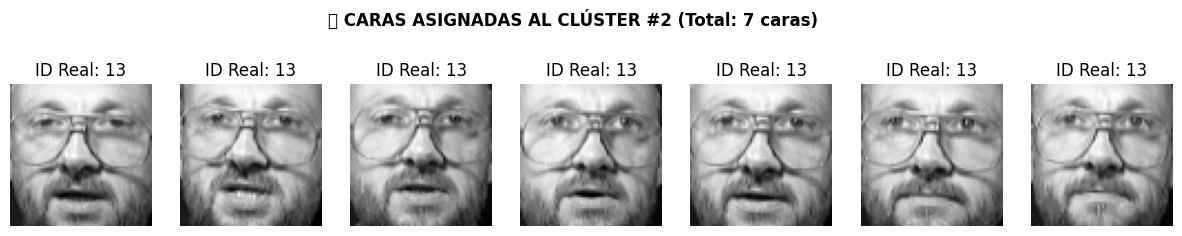

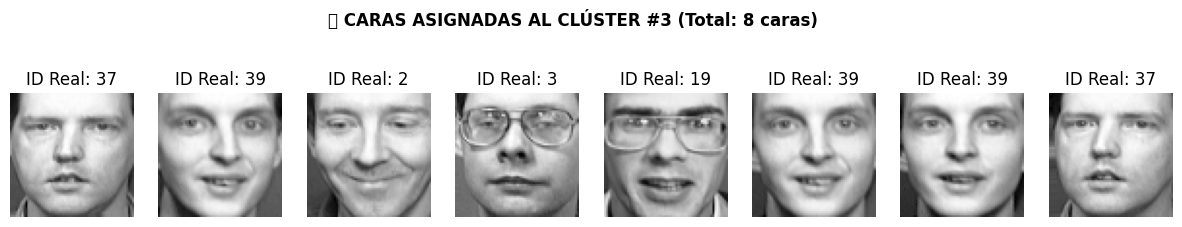

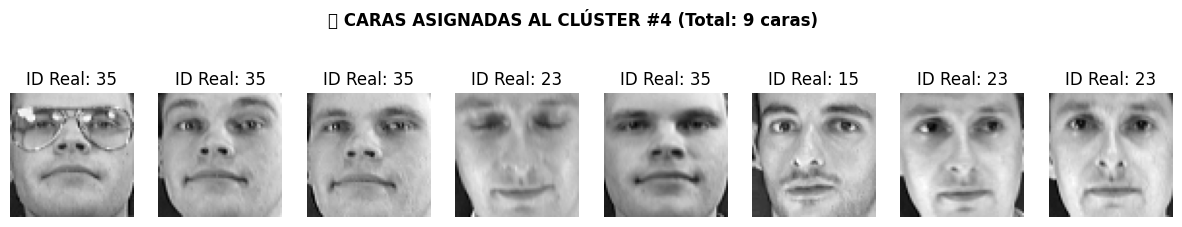

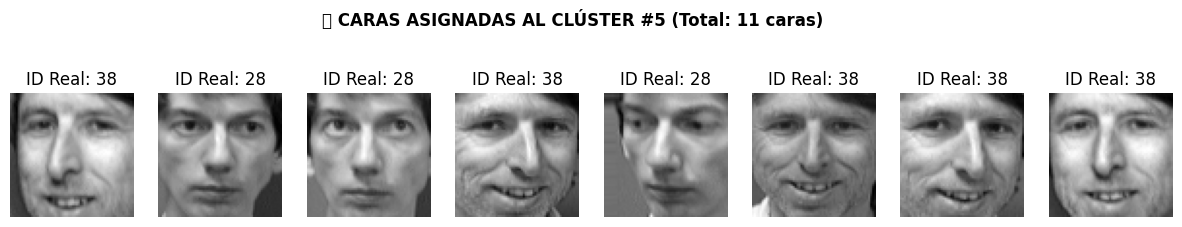

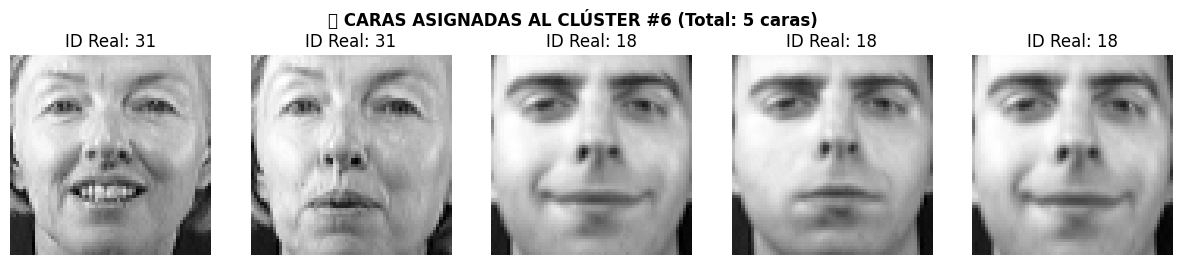

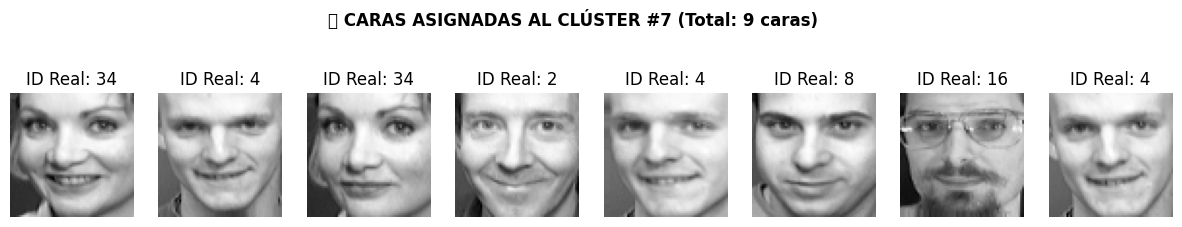

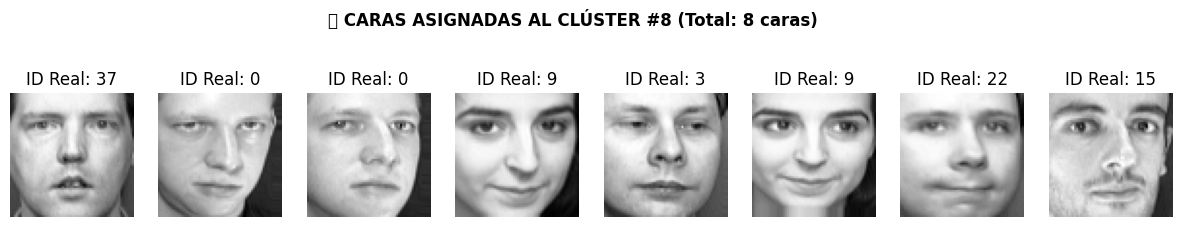

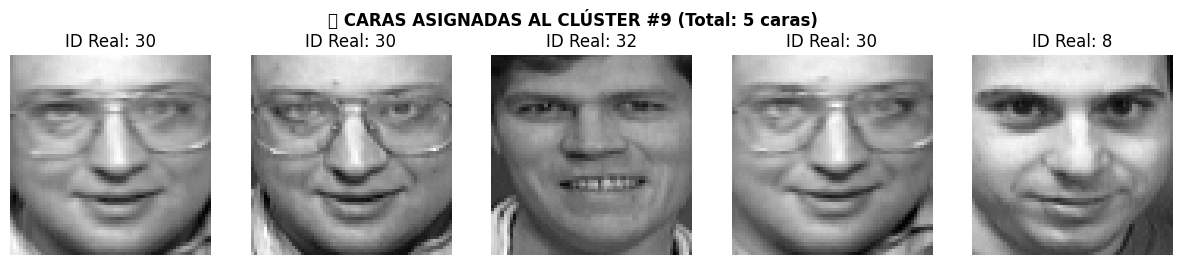

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Entrenar K-Means forzándolo a las 40 identidades teóricas
k_humano = 40
kmeans_40 = KMeans(n_clusters=k_humano, random_state=42, n_init=10)
kmeans_40.fit(X_train)

labels_40 = kmeans_40.labels_

# 2. Vamos a inspeccionar los primeros 3 clústeres para ver qué pasó ahí dentro
for cluster_id in range(10):
    idx_caras = np.where(labels_40 == cluster_id)[0]
    
    # Si el clúster tiene imágenes, las graficamos
    if len(idx_caras) > 0:
        # Limitamos a un máximo de 8 caras por fila para que quepa bien en pantalla
        max_caras = min(len(idx_caras), 8)
        fig, axes = plt.subplots(1, max_caras, figsize=(15, 3))
        fig.suptitle(f"✨ CARAS ASIGNADAS AL CLÚSTER #{cluster_id} (Total: {len(idx_caras)} caras)", fontsize=12, fontweight='bold')
        
        for i in range(max_caras):
            idx = idx_caras[i]
            img = X_train[idx].reshape(64, 64)
            
            ax = axes[i] if max_caras > 1 else axes
            ax.imshow(img, cmap="gray")
            ax.axis("off")
            # Te muestra el ID real de la persona (0 a 39)
            ax.set_title(f"ID Real: {y_train[idx]}")
        plt.show()
    else:
        print(f"El clúster #{cluster_id} quedó vacío.")

El clúster #0 quedó vacío.


c:\Users\sergi\.venvs\ml-cuda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


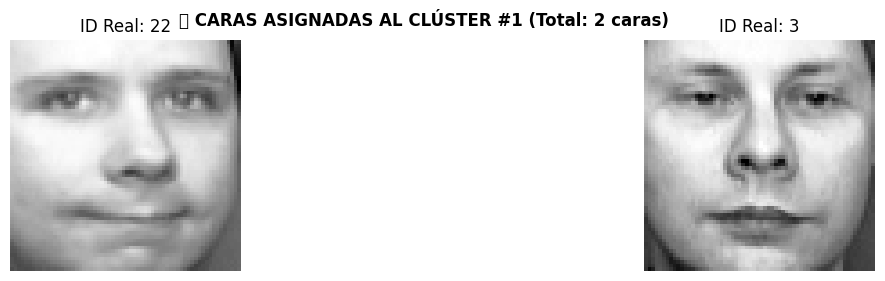

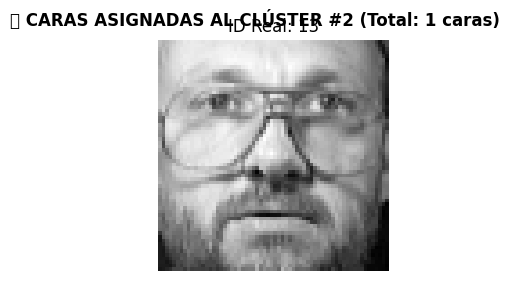

El clúster #3 quedó vacío.


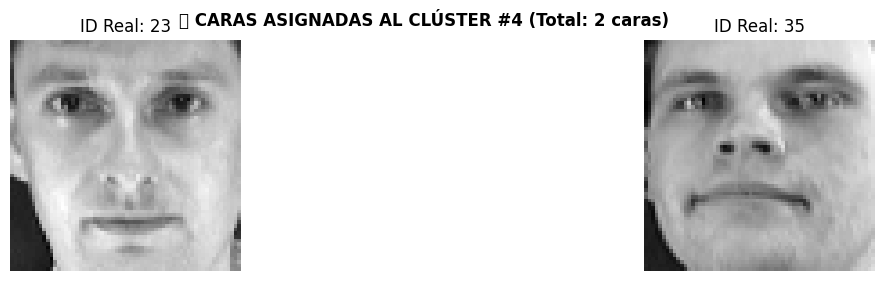

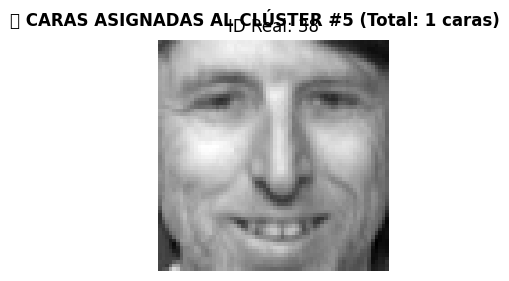

El clúster #6 quedó vacío.


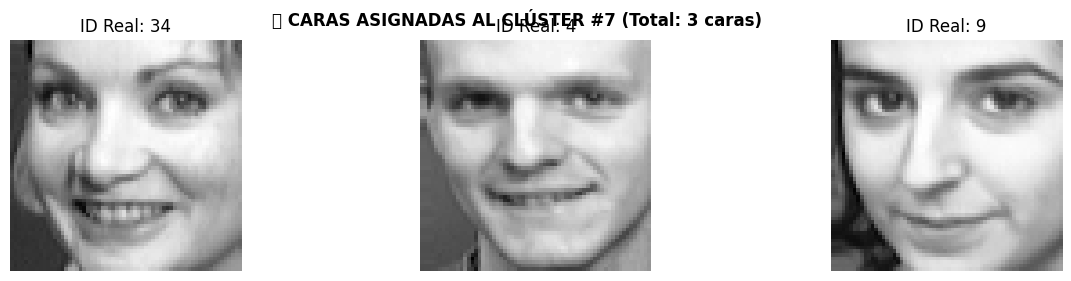

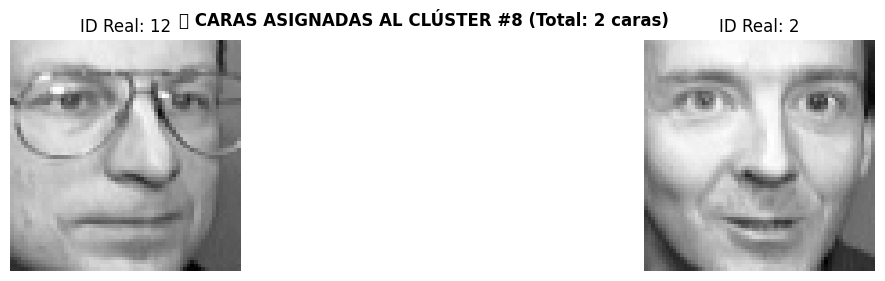

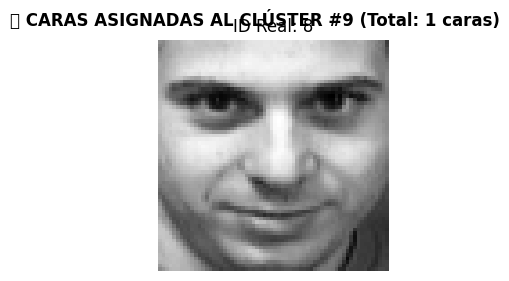

In [7]:
# test on validation set
labels_val_40 = kmeans_40.predict(X_val)
# Vamos a inspeccionar los primeros 3 clústeres para ver qué pasó ahí dentro
for cluster_id in range(10):
    idx_caras_val = np.where(labels_val_40 == cluster_id)[0]
    
    # Si el clúster tiene imágenes, las graficamos
    if len(idx_caras_val) > 0:
        # Limitamos a un máximo de 8 caras por fila para que quepa bien en pantalla
        max_caras = min(len(idx_caras_val), 8)
        fig, axes = plt.subplots(1, max_caras, figsize=(15, 3))
        fig.suptitle(f"✨ CARAS ASIGNADAS AL CLÚSTER #{cluster_id} (Total: {len(idx_caras_val)} caras)", fontsize=12, fontweight='bold')
        
        for i in range(max_caras):
            idx = idx_caras_val[i]
            img = X_val[idx].reshape(64, 64)
            
            ax = axes[i] if max_caras > 1 else axes
            ax.imshow(img, cmap="gray")
            ax.axis("off")
            # Te muestra el ID real de la persona (0 a 39)
            ax.set_title(f"ID Real: {y_val[idx]}")
        plt.show()
    else:
        print(f"El clúster #{cluster_id} quedó vacío.")

c:\Users\sergi\.venvs\ml-cuda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


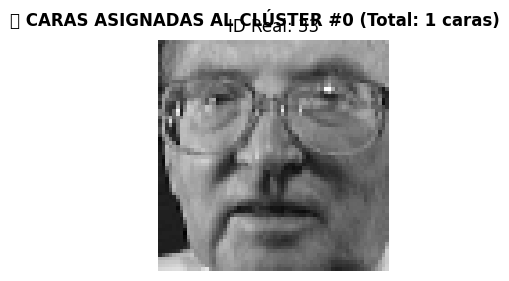

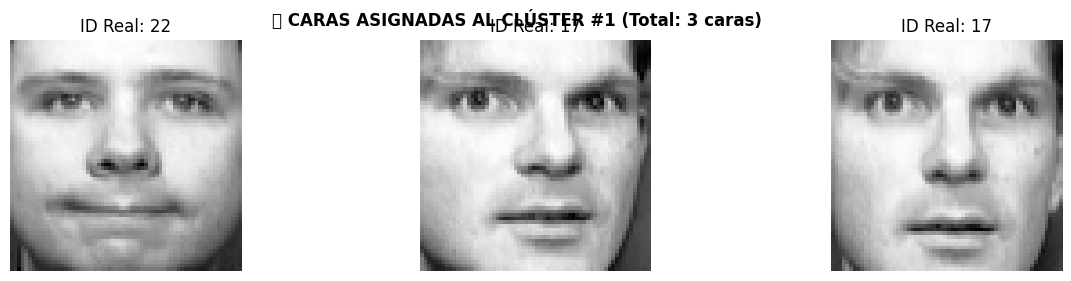

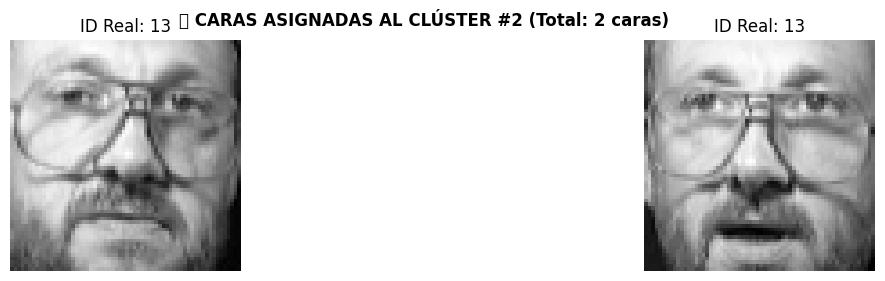

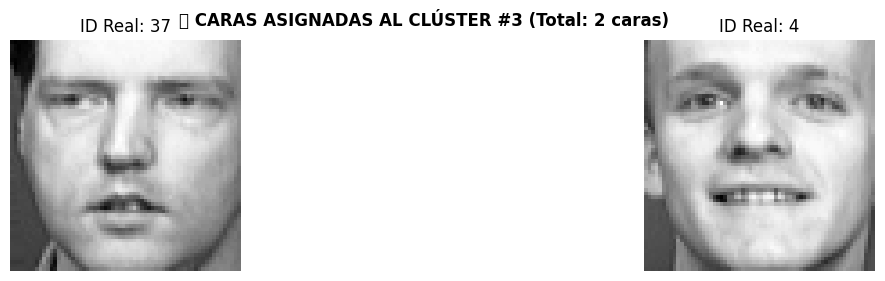

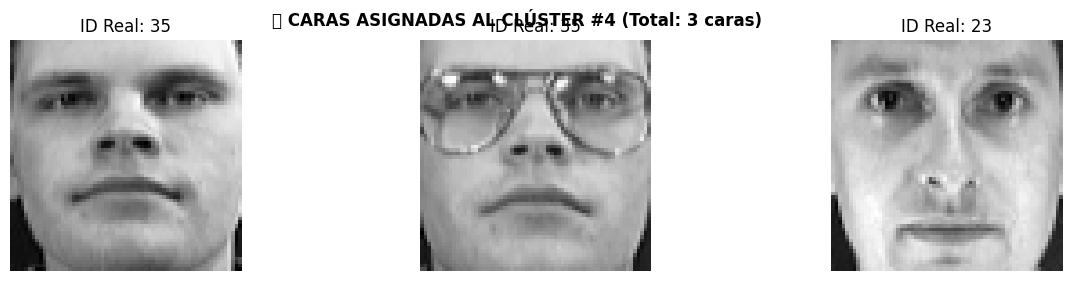

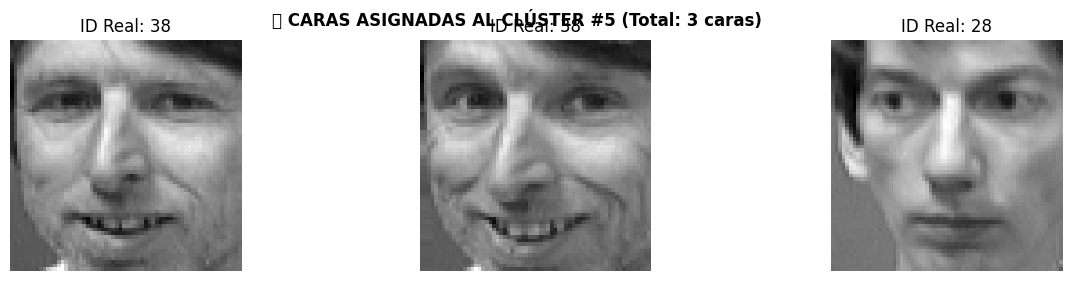

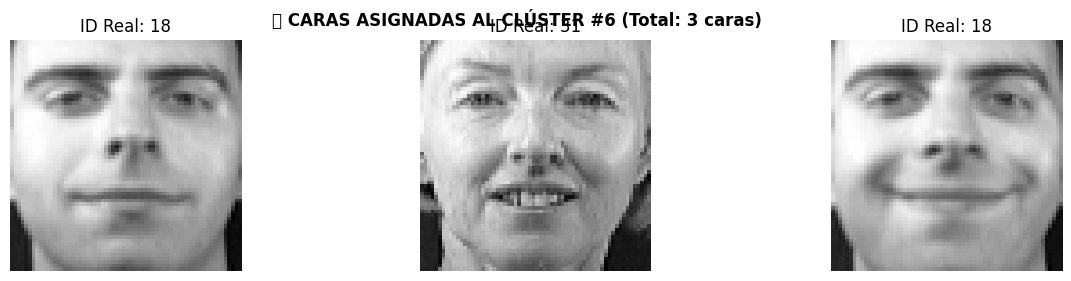

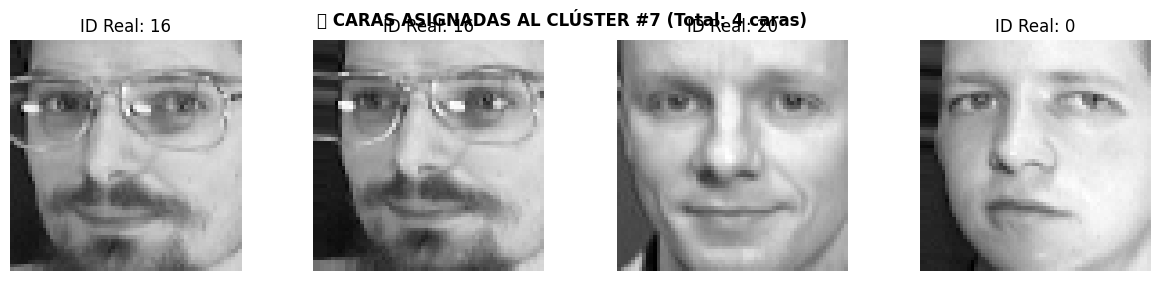

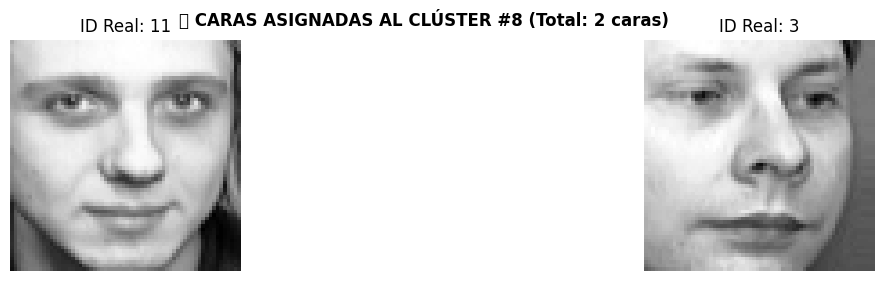

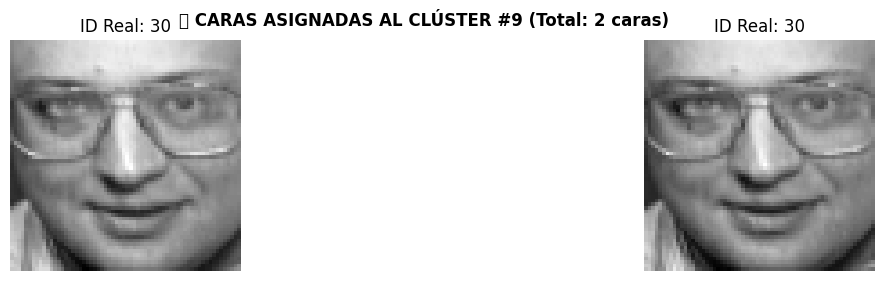

In [8]:
# Test on test set
labels_test_40 = kmeans_40.predict(X_test)
# Vamos a inspeccionar los primeros 3 clústeres para ver qué pasó ahí dentro
for cluster_id in range(10):
    idx_caras_test = np.where(labels_test_40 == cluster_id)[0]
    
    # Si el clúster tiene imágenes, las graficamos
    if len(idx_caras_test) > 0:
        # Limitamos a un máximo de 8 caras por fila para que quepa bien en pantalla
        max_caras = min(len(idx_caras_test), 8)
        fig, axes = plt.subplots(1, max_caras, figsize=(15, 3))
        fig.suptitle(f"✨ CARAS ASIGNADAS AL CLÚSTER #{cluster_id} (Total: {len(idx_caras_test)} caras)", fontsize=12, fontweight='bold')
        
        for i in range(max_caras):
            idx = idx_caras_test[i]
            img = X_test[idx].reshape(64, 64)
            
            ax = axes[i] if max_caras > 1 else axes
            ax.imshow(img, cmap="gray")
            ax.axis("off")
            # Te muestra el ID real de la persona (0 a 39)
            ax.set_title(f"ID Real: {y_test[idx]}")
        plt.show()
    else:
        print(f"El clúster #{cluster_id} quedó vacío.")

In [9]:
from scipy.stats import mode
from sklearn.metrics import accuracy_score

# Build mapping using TRAIN clusters
cluster_to_label = {}

for cluster_id in range(k_humano):
    idx = np.where(labels_40 == cluster_id)[0]
    if len(idx) > 0:
        cluster_to_label[cluster_id] = mode(
            y_train[idx], keepdims=True
        ).mode[0]

# Predict test labels
predicted_labels = np.array([
    cluster_to_label[label] for label in labels_test_40
])

test_accuracy = accuracy_score(y_test, predicted_labels)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.5500


11.  Continuing with the Olivetti faces dataset, train a classifier to predict which
person is represented in each picture, and evaluate it on the validation set. Next,
use k-means as a dimensionality reduction tool, and train a classifier on the
reduced set. Search for the number of clusters that allows the classifier to get
the best performance: what performance can you reach? What if you append the
features from the reduced set to the original features (again, searching for the
best number of clusters)?